# Explainable Machine Learning for LAI Polymer Drug Release

## 1. Introduction

Long-acting injectable (LAI) polymer formulations are designed to release drug over extended time periods, but release profiles depend jointly on formulation, polymer, drug, and time-dependent degradation or diffusion processes. This notebook converts the preliminary Orange analysis into a reproducible Python workflow suitable for an academic paper.

The analysis is organized around nine paper sections: dataset and Orange baseline, reproducible Python workflow, grouped model comparison, zero-shot versus few-shot prediction, full profile prediction by varying only `Time`, SHAP explainability, uncertainty and monotonic correction, and mechanistic chemistry interpretation.

**Main project idea:** predict cumulative fractional release from formulation/drug descriptors, compare zero-shot and few-shot settings, and connect the strongest ML model to interpretable release mechanisms.

### Notebook setup

Run this cell in Colab or a fresh local environment. If the packages are already installed, the cell does nothing.

In [203]:
import importlib.util
import shutil
import subprocess
import sys

REQUIRED_PACKAGES = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "shap": "shap",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl",
    "statsmodels": "statsmodels",
}

missing_packages = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    if shutil.which("uv"):
        cmd = ["uv", "pip", "install", "--python", sys.executable, "-q", *missing_packages]
    else:
        cmd = [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    subprocess.check_call(cmd)
else:
    print("All required packages are already installed.")

All required packages are already installed.


### Reproducibility imports and settings

This section defines the reproducible Python environment used for all downstream analysis. Random seeds, output paths, plotting behavior, and model imports are centralized so the notebook can be run from top to bottom.

In [204]:
import os
import warnings
warnings.filterwarnings("ignore")

# Keep Matplotlib cache inside the project when the user home cache is not writable.
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force white plot backgrounds, including in dark-themed notebook viewers.
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.grid": False,
    "grid.color": "#D0D0D0",
    "grid.alpha": 0.4,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.labelcolor": "black",
})

def force_light_axes(ax):
    fig = ax.figure
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_color("black")
    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_facecolor("white")
        legend.get_frame().set_edgecolor("black")
        for text in legend.get_texts():
            text.set_color("black")

from scipy.optimize import curve_fit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "lai_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

## 2. Dataset and preliminary Orange baseline

The analysis uses `Dataset_17_feat.csv`. The preliminary Orange workflow is treated as the baseline context: it provided the initial EDA, correlation/VIF checks, feature ranking intuition, and a first comparison of common regression models. The Python workflow below makes those steps reproducible and replaces random row splitting with grouped validation.

Expected columns include formulation identifiers (`Experimental_index`, `DP_Group`), polymer/drug descriptors, early release measurements (`T=0.25`, `T=0.5`, `T=1.0`), `Time`, and the target `Release`.

In [205]:
DATA_PATH = "Dataset_17_feat.csv"

# Colab helper: if the file is not present, ask the user to upload it.
# if not os.path.exists(DATA_PATH):
#     try:
#         from google.colab import files
#         print("Dataset_17_feat.csv not found. Please upload it now.")
#         uploaded = files.upload()
#         if "Dataset_17_feat.csv" in uploaded:
#             DATA_PATH = "Dataset_17_feat.csv"
#     except Exception:
#         pass

df = pd.read_csv(DATA_PATH)

# Sort by profile and time. This is useful for profile plotting later.
df = df.sort_values(["Experimental_index", "Time"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3783, 20)


,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
0,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.00,0.04,0.05,0.09,0.00
1,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.17,0.04,0.05,0.09,0.03
2,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,1.03,0.04,0.05,0.09,0.12
3,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,3.26,0.04,0.05,0.09,0.20
4,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,7.04,0.04,0.05,0.09,0.28


Experimental_index      int64
DP_Group               object
LA/GA                 float64
Polymer_MW            float64
CL Ratio              float64
Drug_Tm               float64
Drug_Pka              float64
Initial D/M ratio     float64
DLC                   float64
SA-V                  float64
SE                    float64
Drug_Mw               float64
Drug_TPSA             float64
Drug_NHA              float64
Drug_LogP             float64
Time                  float64
T=0.25                float64
T=0.5                 float64
T=1.0                 float64
Release               float64
dtype: object

### Paper-ready dataset description

The dataset contains individual fractional drug release measurements from multiple long-acting injectable polymer formulations. Each `Experimental_index` represents one release profile measured across time, while `DP_Group` identifies broader drug-polymer groupings. Because rows from the same profile share formulation descriptors and early release measurements, validation must keep all rows from a profile together.

## 3. Python reproducible workflow: target, identifiers, and feature sets

Two supervised prediction settings are defined. The zero-shot setting uses only descriptors available before release testing. The few-shot setting additionally includes early release values (`T=0.25`, `T=0.5`, and `T=1.0`) to test how much predictive value is gained from early experimental measurements.

In [206]:
ID_COLS = ["Experimental_index", "DP_Group"]
TARGET = "Release"
EARLY_FEATURES = ["T=0.25", "T=0.5", "T=1.0"]

# All numeric input columns except identifiers and target.
ALL_FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Zero-shot: no early measured release values.
ZERO_SHOT_FEATURES = [c for c in ALL_FEATURES if c not in EARLY_FEATURES]

# Few-shot: includes early measured release values.
FEW_SHOT_FEATURES = ALL_FEATURES.copy()

# Main grouping variable for profile-aware validation.
# This prevents rows from the same release profile appearing in both train and test.
MAIN_GROUP_COL = "Experimental_index"
STRICT_GROUP_COL = "DP_Group"
GROUP_COL = MAIN_GROUP_COL
groups = df[GROUP_COL]

# Optional stricter validation. Leave False for the main paper results unless explicitly reporting
# drug-polymer-group generalization as a sensitivity analysis.
RUN_STRICT_DP_GROUP_VALIDATION = False

print("All features:", ALL_FEATURES)
print()
print("Zero-shot features:", ZERO_SHOT_FEATURES)
print()
print("Few-shot features:", FEW_SHOT_FEATURES)
print()
print("Main grouped-validation column:", MAIN_GROUP_COL)
print("Optional stricter grouped-validation column:", STRICT_GROUP_COL)
print("Number of unique release profiles:", df["Experimental_index"].nunique())
print("Number of unique drug-polymer groups:", df["DP_Group"].nunique())


All features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Zero-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time']

Few-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Main grouped-validation column: Experimental_index
Optional stricter grouped-validation column: DP_Group
Number of unique release profiles: 181
Number of unique drug-polymer groups: 34


### Paper-ready zero-shot and few-shot definition

Zero-shot prediction used only formulation, polymer, drug, and time descriptors available before release testing. Few-shot prediction used the same descriptors plus early release measurements, which represent a limited experimental preview of the release profile and may capture early burst behavior.

### Reproducible EDA corresponding to the Orange baseline

This section reproduces the key Orange-style checks in Python: missing values, summary statistics, the target distribution, and Spearman correlations. These outputs document the dataset before model training and make the exploratory phase traceable.

In [207]:
OUTPUT_DOB = f"{OUTPUT_DIR}/dataset_and_orange_baseline"
os.makedirs(OUTPUT_DOB, exist_ok=True)
# Missing values
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_percent"] = 100 * missing_table["missing_count"] / len(df)
display(missing_table)

# Basic statistics
display(df.describe().T)

# Save summary table for the paper
df.describe().T.to_csv(os.path.join(OUTPUT_DOB, "summary_statistics.csv"))
missing_table.to_csv(os.path.join(OUTPUT_DOB, "missing_values.csv"))

,missing_count,missing_percent
Experimental_index,0,0.0
DP_Group,0,0.0
LA/GA,0,0.0
Polymer_MW,0,0.0
CL Ratio,0,0.0
Drug_Tm,0,0.0
Drug_Pka,0,0.0
Initial D/M ratio,0,0.0
DLC,0,0.0
SA-V,0,0.0


,count,mean,std,min,25%,50%,75%,max
Experimental_index,3783.0,109.012688,52.938740,1.00,66.000,124.00,154.00,181.00
LA/GA,3783.0,0.804766,1.014624,0.00,0.000,1.00,1.00,3.00
Polymer_MW,3783.0,35788.243458,24367.696754,8300.00,15000.000,32000.00,44000.00,108000.00
CL Ratio,3783.0,0.062950,0.067476,0.00,0.000,0.04,0.15,0.18
Drug_Tm,3783.0,212.501586,66.170200,66.00,206.000,216.50,262.00,312.50
Drug_Pka,3783.0,10.706394,2.532575,4.40,10.360,10.36,11.75,19.69
Initial D/M ratio,3783.0,0.705757,0.626395,0.01,0.115,0.83,1.00,2.50
DLC,3783.0,0.185916,0.129409,0.00,0.060,0.18,0.31,0.62
SA-V,3783.0,696.890563,2298.216607,2.48,2.890,65.93,155.56,22018.35
SE,3783.0,0.292556,0.261045,0.00,0.000,0.50,0.50,1.00


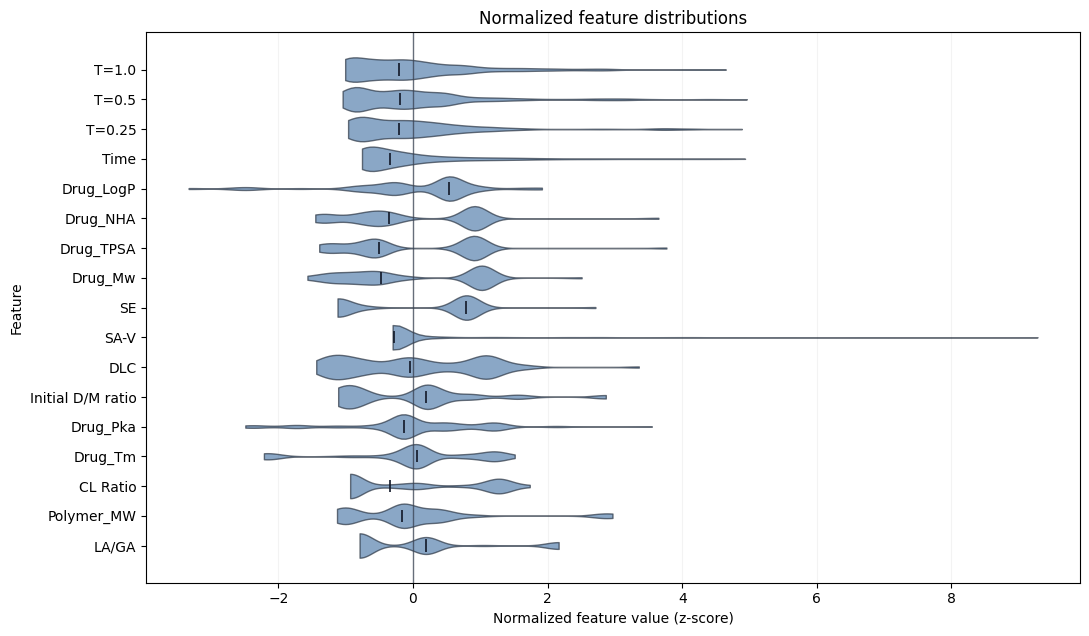

Saved normalized stacked feature violin plot to lai_outputs/dataset_and_orange_baseline/feature_distributions/normalized_feature_distributions_violin.png


In [208]:
# Horizontal stacked violin plot for normalized feature distributions
OUTPUT_DOB = globals().get("OUTPUT_DOB", os.path.join(OUTPUT_DIR, "dataset_and_orange_baseline"))
feature_plot_dir = os.path.join(OUTPUT_DOB, "feature_distributions")
os.makedirs(feature_plot_dir, exist_ok=True)

normalized_violin_path = os.path.join(
    feature_plot_dir,
    "normalized_feature_distributions_violin.png",
)

distribution_features = [feature for feature in ALL_FEATURES if feature in df.columns]
feature_values = df[distribution_features].apply(pd.to_numeric, errors="coerce")
feature_means = feature_values.mean(skipna=True)
feature_stds = feature_values.std(skipna=True, ddof=0).replace(0, np.nan)
normalized_features = (feature_values - feature_means) / feature_stds

plot_data = [
    normalized_features[feature].dropna().to_numpy()
    for feature in distribution_features
]
plot_features = [
    feature
    for feature, values in zip(distribution_features, plot_data)
    if len(values) > 0
]
plot_data = [values for values in plot_data if len(values) > 0]

fig_height = max(6, 0.38 * len(plot_features))
fig, ax = plt.subplots(figsize=(11, fig_height))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
violin_parts = ax.violinplot(
    plot_data,
    positions=np.arange(1, len(plot_features) + 1),
    vert=False,
    widths=0.82,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in violin_parts["bodies"]:
    body.set_facecolor("#4C78A8")
    body.set_edgecolor("#1F2937")
    body.set_alpha(0.65)

if "cmedians" in violin_parts:
    violin_parts["cmedians"].set_color("#111827")
    violin_parts["cmedians"].set_linewidth(1.2)

ax.axvline(0, color="#374151", linewidth=1, alpha=0.75)
ax.set_yticks(np.arange(1, len(plot_features) + 1))
ax.set_yticklabels(plot_features)
ax.set_xlabel("Normalized feature value (z-score)")
ax.set_ylabel("Feature")
ax.set_title("Normalized feature distributions")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(normalized_violin_path, dpi=300, facecolor="white", edgecolor="white", transparent=False)
plt.show()
plt.close(fig)

print(f"Saved normalized stacked feature violin plot to {normalized_violin_path}")

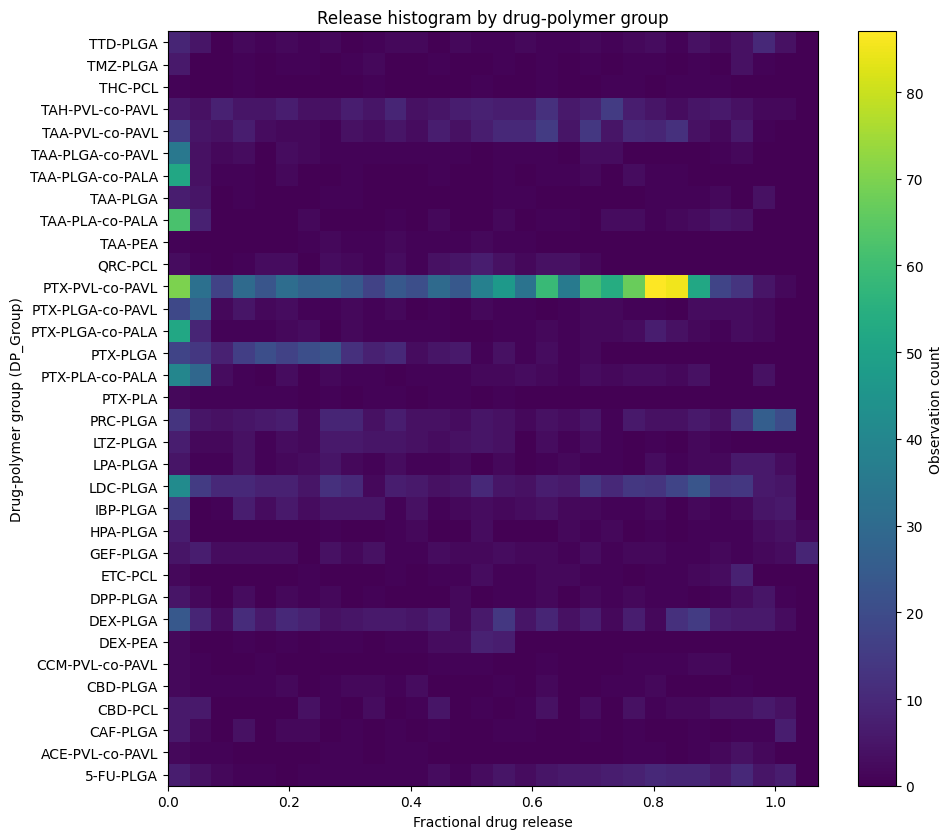

Saved 34 release histograms to lai_outputs/dataset_and_orange_baseline/release_histograms_by_dp_group


In [209]:
# Release histograms by drug-polymer group
GROUP_COL = "DP_Group"
group_order = sorted(df[GROUP_COL].dropna().unique())
group_positions = np.arange(1, len(group_order) + 1)
release_bins = np.linspace(df[TARGET].min(), df[TARGET].max(), 31)
release_hist_dir = os.path.join(OUTPUT_DOB, "release_histograms_by_dp_group")
os.makedirs(release_hist_dir, exist_ok=True)

for group in group_order:
    group_df = df.loc[df[GROUP_COL].eq(group)]
    safe_group = str(group).replace("/", "_").replace(" ", "_").replace("=", "")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(group_df[TARGET].dropna(), bins=release_bins, alpha=0.85)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Observation count")
    ax.set_title(f"Release histogram: {group}")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        os.path.join(release_hist_dir, f"release_{safe_group}_histogram.png"),
        dpi=300,
    )
    plt.close(fig)

# Overview: binned release counts per group, with group on the y-axis.
release_hist = np.vstack([
    np.histogram(
        df.loc[df[GROUP_COL].eq(group), TARGET].dropna(),
        bins=release_bins,
    )[0]
    for group in group_order
])

fig, ax = plt.subplots(figsize=(10, max(8, 0.25 * len(group_order))))
image = ax.imshow(
    release_hist,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[release_bins[0], release_bins[-1], 0.5, len(group_order) + 0.5],
)

ax.set_yticks(group_positions)
ax.set_yticklabels(group_order)
ax.set_xlabel("Fractional drug release")
ax.set_ylabel("Drug-polymer group (DP_Group)")
ax.set_title("Release histogram by drug-polymer group")
plt.colorbar(image, ax=ax, label="Observation count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DOB, "release_histogram_by_dp_group_overview.png"), dpi=300)
plt.show()

print(f"Saved {len(group_order)} release histograms to {release_hist_dir}")

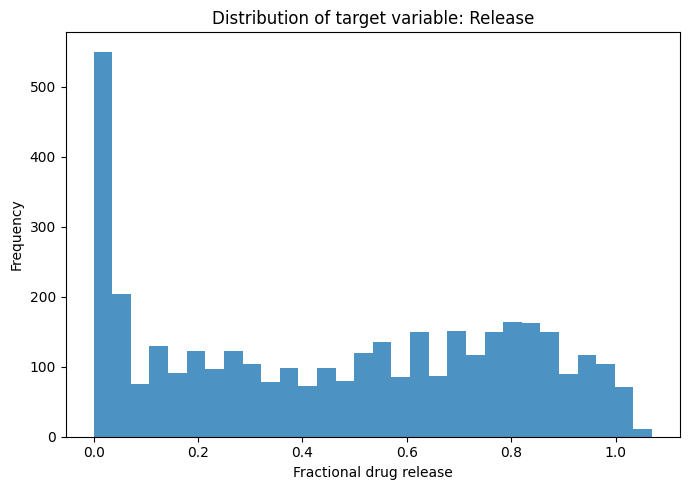

In [210]:
plt.figure(figsize=(7, 5))
plt.hist(df[TARGET], bins=30, alpha=0.8)
plt.xlabel("Fractional drug release")
plt.ylabel("Frequency")
plt.title("Distribution of target variable: Release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DOB, "target_distribution.png"), dpi=300)
plt.show()

In [ ]:
# Separate Release histograms by group and by individual release profile
GROUP_COL = "DP_Group"
PROFILE_COL = "Experimental_index"
SHOW_PLOTS = False  # Set to True if you want every histogram displayed in the notebook.

def safe_filename(value):
    return (
        str(value)
        .replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
        .replace("=", "")
    )

release_bins = np.linspace(df[TARGET].min(), df[TARGET].max(), 31)

group_hist_dir = os.path.join(OUTPUT_DOB, "release_histograms_by_group")
profile_hist_root = os.path.join(OUTPUT_DOB, "release_histograms_by_group_profile")
os.makedirs(group_hist_dir, exist_ok=True)
os.makedirs(profile_hist_root, exist_ok=True)

# One separate histogram for each drug-polymer group.
for group, group_df in df.groupby(GROUP_COL, sort=True):
    safe_group = safe_filename(group)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(group_df[TARGET].dropna(), bins=release_bins, alpha=0.8)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of Release: {group}")
    fig.tight_layout()
    fig.savefig(
        os.path.join(group_hist_dir, f"release_{safe_group}_histogram.png"),
        dpi=300,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

# One separate histogram for each individual profile inside each group.
profile_count = 0
for (group, profile_id), profile_df in df.groupby([GROUP_COL, PROFILE_COL], sort=True):
    safe_group = safe_filename(group)
    safe_profile = safe_filename(profile_id)
    profile_hist_dir = os.path.join(profile_hist_root, safe_group)
    os.makedirs(profile_hist_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(profile_df[TARGET].dropna(), bins=release_bins, alpha=0.8)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of Release: {group}, profile {profile_id}")
    fig.tight_layout()
    fig.savefig(
        os.path.join(
            profile_hist_dir,
            f"release_{safe_group}_profile_{safe_profile}_histogram.png",
        ),
        dpi=300,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)
    profile_count += 1

print(f"Saved {df[GROUP_COL].nunique()} separate group histograms to {group_hist_dir}")
print(f"Saved {profile_count} separate group/profile histograms to {profile_hist_root}")


In [ ]:
# Correlation matrix for numeric features and target
corr_cols = ALL_FEATURES + [TARGET]
corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Spearman correlation")
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DOB, "spearman_correlation_matrix.png"), dpi=300)
plt.show()

# Save correlation matrix
corr.to_csv(os.path.join(OUTPUT_DOB, "spearman_correlation_matrix.csv"))

### Paper comment: EDA

> Exploratory analysis was repeated in Python to make the workflow reproducible. Missing values, descriptive statistics, target distribution, and correlation structure were examined before model training. This step is important because several descriptors describe related physicochemical properties, so redundancy and multicollinearity are expected.

### Optional VIF analysis for the linear baseline

VIF is mainly useful for linear models.  
Tree-based models can handle correlated features better, but VIF is still useful as a connection to the Orange homework.

In [ ]:
# Optional VIF function.
# statsmodels may not be installed in every environment, so install if needed.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import shutil
    import subprocess
    import sys
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--python", sys.executable, "-q", "statsmodels"])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe, features):
    X_vif = dataframe[features].copy()
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

    # VIF requires numeric features and no constant duplicate problems.
    X_values = X_vif.values

    rows = []
    for i, col in enumerate(features):
        try:
            vif_value = variance_inflation_factor(X_values, i)
        except Exception:
            vif_value = np.nan
        rows.append({"Feature": col, "VIF": vif_value})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(df, ALL_FEATURES)
display(vif_table)

vif_table.to_csv(os.path.join(OUTPUT_DOB, "vif_all_features.csv"), index=False)


In [ ]:
def iterative_vif_selection(dataframe, features, threshold=5.0):
    selected = features.copy()
    history = []

    while True:
        vif_table = calculate_vif(dataframe, selected)
        max_vif = vif_table["VIF"].max()

        if pd.isna(max_vif) or max_vif <= threshold:
            break

        remove_feature = vif_table.iloc[0]["Feature"]
        history.append({
            "removed_feature": remove_feature,
            "max_vif": max_vif,
            "remaining_features": len(selected) - 1
        })
        selected.remove(remove_feature)

    final_vif = calculate_vif(dataframe, selected)
    return selected, pd.DataFrame(history), final_vif

vif_selected_features, vif_history, final_vif = iterative_vif_selection(df, ALL_FEATURES, threshold=5.0)

print("Selected features after iterative VIF:")
print(vif_selected_features)

display(vif_history)
display(final_vif)

vif_history.to_csv(os.path.join(OUTPUT_DOB, "vif_elimination_history.csv"), index=False)
final_vif.to_csv(os.path.join(OUTPUT_DOB, "vif_selected_features.csv"), index=False)

### Paper comment: VIF

> VIF analysis was used only to support the interpretation of linear models. After iterative elimination of highly collinear predictors, a reduced feature set can be used for Ridge/MLR-style baselines. However, the main predictive models in this project are tree-based because the Orange homework already suggested that the release process is not purely linear.

### Profile-aware grouped validation

A random row split is not appropriate because time points from the same release profile are strongly related. The main validation strategy is `GroupKFold` with `Experimental_index`, ensuring that every profile appears entirely in either the training or test fold. `DP_Group` is reserved for optional stricter validation because it tests generalization to broader unseen drug-polymer groups.

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def make_group_splits(X, y, group_values, n_splits=5):
    n_groups = pd.Series(group_values).nunique()
    if n_groups < n_splits:
        raise ValueError(f"Need at least {n_splits} groups for GroupKFold, but found {n_groups}.")
    splitter = GroupKFold(n_splits=n_splits)
    return splitter.split(X, y, group_values)

def evaluate_group_cv(model, X, y, group_values, n_splits=5, group_col=MAIN_GROUP_COL, source_df=None):
    '''
    Evaluates a regression model using GroupKFold.

    The default grouping column is Experimental_index. DP_Group should be used only
    for an optional stricter sensitivity analysis.
    '''
    if source_df is None:
        source_df = df.loc[X.index]

    group_values = pd.Series(group_values, index=X.index)
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=float)
    oof_fold = np.zeros(len(y), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(X, y, group_values, n_splits=n_splits)):
        model_fold = clone(model)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold.fit(X_train, y_train)
        pred = np.ravel(model_fold.predict(X_test))

        oof_pred[test_idx] = pred
        oof_fold[test_idx] = fold

        metrics = regression_metrics(y_test, pred)
        metrics["fold"] = fold
        metrics["group_col"] = group_col
        metrics["n_test_rows"] = len(test_idx)
        metrics["n_test_groups"] = group_values.iloc[test_idx].nunique()
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "group_col": group_col,
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std()
    }

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "y_pred": oof_pred,
        "fold": oof_fold,
        "group_col": group_col,
        "Experimental_index": source_df["Experimental_index"].values,
        "DP_Group": source_df["DP_Group"].values,
        "Time": source_df["Time"].values
    })

    return fold_df, summary, oof_df

### Paper-ready validation statement

Model performance was evaluated using profile-aware `GroupKFold` cross-validation. The primary grouping variable was `Experimental_index`, so all measurements from a release profile were assigned to the same fold. This avoids overly optimistic performance estimates caused by training on some time points from a profile and testing on other time points from the same profile. Validation by `DP_Group` is included only as a stricter optional sensitivity analysis.

## 4. Baseline model comparison: Ridge, PLS, RF, GB, XGBoost, LightGBM, CatBoost

The Orange baseline is repeated and extended in Python using grouped validation. Linear models (Ridge and PLS) provide interpretable low-complexity references, while tree-based ensembles test nonlinear relationships among polymer, drug, formulation, and time variables.

In [ ]:
OUTPUT_BMC=f'{OUTPUT_DIR}/baseline_model_comparison'
os.makedirs(OUTPUT_BMC, exist_ok=True)

def make_lgbm_regressor(n_estimators=700, learning_rate=0.025):
    return LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbose=-1
    )

def make_catboost_regressor(iterations=700, learning_rate=0.025):
    return CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1
    )

def make_direct_tree_model(model_name):
    if model_name == "CatBoost":
        return make_catboost_regressor(iterations=700, learning_rate=0.025)
    if model_name == "LightGBM":
        return make_lgbm_regressor(n_estimators=700, learning_rate=0.025)
    raise ValueError(f"Unsupported direct model: {model_name}")

models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "PLS": make_pipeline(StandardScaler(), PLSRegression(n_components=5)),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": make_lgbm_regressor(n_estimators=500, learning_rate=0.03),
    "CatBoost": make_catboost_regressor(iterations=500, learning_rate=0.03)
}

X_all = df[ALL_FEATURES]
y = df[TARGET]

baseline_rows = []
baseline_oof = {}

for name, model in models.items():
    print(f"Evaluating: {name}")
    fold_df, summary, oof_df = evaluate_group_cv(model, X_all, y, groups, n_splits=5)
    row = {"model": name, **summary}
    baseline_rows.append(row)
    baseline_oof[name] = oof_df

baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE_mean")
display(baseline_results)


selected_baseline_row = baseline_results.sort_values("MAE_mean").iloc[0]
selected_direct_model_name = selected_baseline_row["model"]
selected_direct_model_mae = selected_baseline_row["MAE_mean"]

print("Direct model selected for sections 5 onward:", selected_direct_model_name)

baseline_results.to_csv(os.path.join(OUTPUT_BMC, "baseline_groupcv_results.csv"), index=False)

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(baseline_results["model"], baseline_results["MAE_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean MAE across GroupKFold")
plt.title("Baseline model comparison with profile-aware validation")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BMC, "baseline_model_comparison_mae.png"), dpi=300)
plt.show()

### Paper-ready baseline model comparison

The preliminary Orange model comparison was repeated in Python with profile-aware grouped validation across Ridge, PLS, Random Forest, Gradient Boosting, XGBoost, LightGBM, and CatBoost. After this full baseline comparison, LightGBM and CatBoost were compared as the final direct gradient-boosting candidates. LightGBM gives the lower grouped-validation `MAE_mean`, so the remaining analyses use LightGBM as the selected direct model.

## 5. Zero-shot vs few-shot prediction

This comparison separates two practically different use cases. Zero-shot prediction estimates the full release profile from pre-experimental descriptors only. Few-shot prediction includes early release measurements and therefore tests whether limited early experimental data improves prediction of later release behavior. The model used here is LightGBM, selected as the best-performing model from the full section 4 baseline comparison.

In [ ]:
OUTPUT_ZSFS=f'{OUTPUT_DIR}/zero_vs_few_shot'
os.makedirs(OUTPUT_ZSFS, exist_ok=True)

zero_model = make_direct_tree_model(selected_direct_model_name)
few_model = make_direct_tree_model(selected_direct_model_name)

X_zero = df[ZERO_SHOT_FEATURES]
X_few = df[FEW_SHOT_FEATURES]

print(f"Using {selected_direct_model_name} for zero-shot and few-shot prediction.")

zero_fold_df, zero_summary, zero_oof = evaluate_group_cv(
    zero_model, X_zero, y, groups, n_splits=5
)

few_fold_df, few_summary, few_oof = evaluate_group_cv(
    few_model, X_few, y, groups, n_splits=5
)

zero_few_results = pd.DataFrame([
    {"scenario": "Zero-shot", "model": selected_direct_model_name, **zero_summary},
    {"scenario": "Few-shot", "model": selected_direct_model_name, **few_summary}
]).sort_values("MAE_mean")

display(zero_few_results)

zero_few_results.to_csv(os.path.join(OUTPUT_ZSFS, "zero_vs_few_shot_results.csv"), index=False)
zero_oof.to_csv(os.path.join(OUTPUT_ZSFS, "zero_shot_oof_predictions.csv"), index=False)
few_oof.to_csv(os.path.join(OUTPUT_ZSFS, "few_shot_oof_predictions.csv"), index=False)

### Optional stricter validation by `DP_Group`

The primary paper results should use `Experimental_index` grouping. If the goal is to test generalization to entirely unseen drug-polymer groups, set `RUN_STRICT_DP_GROUP_VALIDATION = True` above and rerun the notebook.

In [ ]:
RUN_STRICT_DP_GROUP_VALIDATION = True
if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_groups = df[STRICT_GROUP_COL]

    strict_zero_fold_df, strict_zero_summary, strict_zero_oof = evaluate_group_cv(
        zero_model,
        X_zero,
        y,
        strict_groups,
        n_splits=5,
        group_col=STRICT_GROUP_COL
    )

    strict_few_fold_df, strict_few_summary, strict_few_oof = evaluate_group_cv(
        few_model,
        X_few,
        y,
        strict_groups,
        n_splits=5,
        group_col=STRICT_GROUP_COL
    )

    strict_zero_few_results = pd.DataFrame([
        {"scenario": "Zero-shot, DP_Group strict", **strict_zero_summary},
        {"scenario": "Few-shot, DP_Group strict", **strict_few_summary}
    ]).sort_values("MAE_mean")

    display(strict_zero_few_results)
    strict_zero_few_results.to_csv(os.path.join(OUTPUT_ZSFS, "zero_vs_few_shot_results_dp_group.csv"), index=False)
    strict_zero_oof.to_csv(os.path.join(OUTPUT_ZSFS, "zero_shot_oof_predictions_dp_group.csv"), index=False)
    strict_few_oof.to_csv(os.path.join(OUTPUT_ZSFS, "few_shot_oof_predictions_dp_group.csv"), index=False)
else:
    print("Strict DP_Group validation skipped. Set RUN_STRICT_DP_GROUP_VALIDATION = True to enable it.")

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(zero_oof["y_true"], zero_oof["y_pred"], alpha=0.25, label="Zero-shot")
plt.scatter(few_oof["y_true"], few_oof["y_pred"], alpha=0.25, label="Few-shot")
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Predicted release")
plt.title("Zero-shot vs few-shot prediction")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "zero_vs_few_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper-ready zero-shot vs few-shot result

The zero-shot and few-shot models were evaluated with the same `Experimental_index` grouped folds. The estimator is the section 4 selected direct model: LightGBM. Improvement in the few-shot setting indicates that early release values contain useful information about burst release and downstream kinetic behavior that is not fully captured by static formulation descriptors alone.

## 6. Full release profile prediction by varying only Time

A final direct tree model is trained on all rows after cross-validation has estimated generalization performance. This section uses the section 4 selected direct model, LightGBM. For profile visualization, formulation and drug descriptors are fixed for one `Experimental_index`, and only `Time` is varied over a continuous grid.

In [ ]:
OUTPUT_FRPBT=f'{OUTPUT_DIR}/full_release_prediction_by_time'
os.makedirs(OUTPUT_FRPBT, exist_ok=True)

best_direct_model = make_direct_tree_model(selected_direct_model_name)
best_direct_model.fit(X_few, y)

print(f"Final direct model trained on all few-shot rows: {selected_direct_model_name}")

In [ ]:
def predict_release_profile(model, data, profile_id, features, n_points=120, use_observed_time_range=True):
    '''
    Predicts a continuous release profile by:
    - selecting one formulation,
    - keeping formulation/drug descriptors fixed,
    - varying only Time over a grid.
    '''
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    if profile.empty:
        raise ValueError(f"Profile ID {profile_id} not found.")

    base_row = profile.iloc[0].copy()

    if use_observed_time_range:
        t_min = profile["Time"].min()
        t_max = profile["Time"].max()
    else:
        t_min = 0
        t_max = data["Time"].max()

    time_grid = np.linspace(t_min, t_max, n_points)

    X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
    X_grid["Time"] = time_grid

    pred = np.ravel(model.predict(X_grid[features]))

    return profile, time_grid, pred

# Choose a few example profiles for plotting.
example_profiles = df["Experimental_index"].drop_duplicates().sample(
    min(4, df["Experimental_index"].nunique()),
    random_state=RANDOM_STATE
).tolist()

for profile_id in example_profiles:
    profile, time_grid, pred = predict_release_profile(
        best_direct_model,
        df,
        profile_id,
        FEW_SHOT_FEATURES
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(time_grid, pred, label="Predicted full profile")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Full-profile prediction: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FRPBT, f"profile_prediction_{profile_id}.png"), dpi=300)
    plt.show()

In [ ]:
def evaluate_full_profile_time_cv(model_factory, data, features, target_col=TARGET, group_col=MAIN_GROUP_COL, n_splits=5):
    '''
    Evaluates section 6 full-profile prediction on unseen grouped data.

    For each held-out profile, descriptors are fixed from the first profile row and
    only Time is varied over that profile's observed test times.
    '''
    X = data[features]
    y = data[target_col]
    group_values = data[group_col]

    fold_rows = []
    pred_rows = []

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(X, y, group_values, n_splits=n_splits)):
        model_fold = model_factory()
        model_fold.fit(X.iloc[train_idx], y.iloc[train_idx])

        test_data = data.iloc[test_idx].copy()
        fold_true = []
        fold_pred = []

        for profile_id, profile in test_data.groupby("Experimental_index", sort=False):
            profile = profile.sort_values("Time").copy()
            base_row = profile.iloc[0]

            X_profile = pd.DataFrame([base_row[features].to_dict()] * len(profile), index=profile.index)
            X_profile["Time"] = profile["Time"].values
            pred = np.ravel(model_fold.predict(X_profile[features]))

            fold_true.extend(profile[target_col].values)
            fold_pred.extend(pred)

            pred_rows.extend([
                {
                    "scenario": "Full profile time-only",
                    "fold": fold,
                    "group_col": group_col,
                    "Experimental_index": row.Experimental_index,
                    "DP_Group": row.DP_Group,
                    "Time": row.Time,
                    "y_true": row.Release,
                    "y_pred": pred_value,
                }
                for row, pred_value in zip(profile.itertuples(index=False), pred)
            ])

        metrics = regression_metrics(np.asarray(fold_true), np.asarray(fold_pred))
        metrics["fold"] = fold
        metrics["group_col"] = group_col
        metrics["n_test_rows"] = len(test_idx)
        metrics["n_test_groups"] = test_data[group_col].nunique()
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "scenario": "Full profile time-only",
        "group_col": group_col,
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std(),
    }

    return fold_df, summary, pd.DataFrame(pred_rows)


full_profile_fold_df, full_profile_summary, full_profile_oof = evaluate_full_profile_time_cv(
    lambda: make_direct_tree_model(selected_direct_model_name),
    df,
    FEW_SHOT_FEATURES,
    group_col=MAIN_GROUP_COL,
    n_splits=5,
)

full_profile_results = pd.DataFrame([full_profile_summary])[
    ["scenario", "group_col", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
]

display(full_profile_results)

full_profile_results.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_results.csv"), index=False)
full_profile_fold_df.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_fold_metrics.csv"), index=False)
full_profile_oof.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_oof_predictions.csv"), index=False)

if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_full_profile_fold_df, strict_full_profile_summary, strict_full_profile_oof = evaluate_full_profile_time_cv(
        lambda: make_direct_tree_model(selected_direct_model_name),
        df,
        FEW_SHOT_FEATURES,
        group_col=STRICT_GROUP_COL,
        n_splits=5,
    )

    strict_full_profile_results = pd.DataFrame([strict_full_profile_summary])[
        ["scenario", "group_col", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
    ]

    display(strict_full_profile_results)

    strict_full_profile_results.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_results_dp_group.csv"), index=False)
    strict_full_profile_fold_df.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_fold_metrics_dp_group.csv"), index=False)
    strict_full_profile_oof.to_csv(os.path.join(OUTPUT_FRPBT, "full_profile_time_only_oof_predictions_dp_group.csv"), index=False)
else:
    print("Strict DP_Group full-profile validation skipped. Set RUN_STRICT_DP_GROUP_VALIDATION = True to enable it.")


### Paper-ready full-profile prediction

The selected direct model can be used as a continuous release-profile predictor by holding formulation descriptors constant and varying only `Time`. This produces a smooth predicted trajectory that can be plotted against the experimental time points for a selected formulation.

## 7. SHAP explainability

SHAP values are used to interpret the final selected tree model from section 4: LightGBM. The global beeswarm plot summarizes the strongest predictors, while feature-specific dependence plots support mechanistic interpretation of `Time`, polymer descriptors, drug descriptors, and early release measurements.

In [ ]:
import shap
OUTPUT_SHAP=f'{OUTPUT_DIR}/shap_explainability'
os.makedirs(OUTPUT_SHAP, exist_ok=True)

# Use a sample for faster SHAP computation.
X_shap = X_few.sample(min(1200, len(X_few)), random_state=RANDOM_STATE)

print(f"Running SHAP for selected model: {selected_direct_model_name}")
explainer = shap.TreeExplainer(best_direct_model)
shap_values = explainer(X_shap)

# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_SHAP, "shap_beeswarm.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    "model": selected_direct_model_name
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance)
shap_importance.to_csv(os.path.join(OUTPUT_SHAP, "shap_feature_importance.csv"), index=False)

In [ ]:
# Dependence/scatter plots for selected features
for feature in ["Time", "Polymer_MW", "T=1.0", "Drug_Mw", "SA-V", "DLC", "LA/GA", "Drug_LogP"]:
    if feature in X_shap.columns:
        shap.plots.scatter(shap_values[:, feature], show=False)
        plt.tight_layout()
        safe_name = feature.replace("/", "_").replace("=", "").replace(" ", "_")
        plt.savefig(os.path.join(OUTPUT_SHAP, f"shap_scatter_{safe_name}.png"), dpi=300, bbox_inches="tight")
        plt.show()

In [ ]:
# Waterfall plot for one prediction
example_index = 0
shap.plots.waterfall(shap_values[example_index], max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_SHAP, "shap_waterfall_example.png"), dpi=300, bbox_inches="tight")
plt.show()

### Paper-ready SHAP interpretation

SHAP analysis was performed on the section 4 selected direct tree model, LightGBM. The interpretation connects predictive performance with formulation science, including release time, early burst, polymer molecular weight, surface-area-to-volume ratio, drug loading, lactide/glycolide composition, molecular size, and lipophilicity.

## 8. Uncertainty / monotonic correction

Cumulative release should generally remain bounded and non-decreasing over time. This section applies a post hoc monotonic correction, optionally compares a LightGBM model constrained to be monotonic in `Time`, and estimates simple residual-based prediction intervals from grouped cross-validation errors.

In [ ]:
OUTPUT_UMC=(f'{OUTPUT_DIR}/uncertainty_monotonic_correction')
os.makedirs(OUTPUT_UMC, exist_ok=True)

def monotonic_correct(pred, lower=0, upper=1.05):
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, lower, upper)
    pred = np.maximum.accumulate(pred)
    return pred

# Examples: raw vs corrected prediction
for profile_id in example_profiles:
    profile, time_grid, pred_raw = predict_release_profile(
        best_direct_model,
        df,
        profile_id,
        FEW_SHOT_FEATURES
    )

    pred_corrected = monotonic_correct(pred_raw)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(profile["Time"], profile["Release"], label="Experimental")
    ax.plot(time_grid, pred_raw, label="Raw ML prediction", alpha=0.7)
    ax.plot(time_grid, pred_corrected, label="Monotonic corrected prediction")
    ax.set_xlabel("Time")
    ax.set_ylabel("Fractional drug release")
    ax.set_title(f"Monotonic correction: Experimental_index={profile_id}")
    ax.legend()
    force_light_axes(ax)
    fig.tight_layout()
    fig.savefig(
        os.path.join(OUTPUT_UMC, f"monotonic_correction_{profile_id}.png"),
        dpi=300,
        facecolor="white",
        edgecolor="white",
        transparent=False,
    )
    plt.show()
    plt.close(fig)

### Optional: LightGBM monotonic constraint on `Time`

This forces the model to learn a non-decreasing relationship with `Time`.

Use it as an additional experiment, not necessarily as your main model.

In [ ]:
monotone_constraints = [
    1 if feature == "Time" else 0
    for feature in FEW_SHOT_FEATURES
]

monotonic_lgbm = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    monotone_constraints=monotone_constraints,
    random_state=RANDOM_STATE,
    verbose=-1
)

mono_fold_df, mono_summary, mono_oof = evaluate_group_cv(
    monotonic_lgbm,
    X_few,
    y,
    groups,
    n_splits=5
)

display(pd.DataFrame([
    {"model": "LightGBM raw few-shot", **few_summary},
    {"model": "LightGBM monotonic on Time", **mono_summary}
]))

### Paper-ready monotonic correction

Since cumulative release should generally increase over time, predictions were checked for physical plausibility. A post hoc monotonic correction was applied by clipping predictions to a plausible range and enforcing a non-decreasing trajectory. A monotonic LightGBM constraint on `Time` was also evaluated as an optional model-based alternative.

### Simple uncertainty interval from cross-validation residuals

This is not a full Bayesian uncertainty model, but it is simple and useful.

We use cross-validated residuals from the few-shot LightGBM model:
- calculate absolute errors,
- take the 90th percentile,
- use it as an approximate prediction interval width.

In [ ]:
# Absolute residuals from the few-shot OOF predictions
few_oof["abs_error"] = np.abs(few_oof["y_true"] - few_oof["y_pred"])

q80 = np.quantile(few_oof["abs_error"], 0.80)
q90 = np.quantile(few_oof["abs_error"], 0.90)
q95 = np.quantile(few_oof["abs_error"], 0.95)

print("Approximate residual interval widths:")
print("80%:", q80)
print("90%:", q90)
print("95%:", q95)

# Plot selected profiles with approximate intervals.
for profile_id in example_profiles[:2]:
    profile, time_grid, pred = predict_release_profile(
        best_direct_model,
        df,
        profile_id,
        FEW_SHOT_FEATURES
    )

    pred_corr = monotonic_correct(pred)
    lower = np.clip(pred_corr - q90, 0, 1.05)
    upper = np.clip(pred_corr + q90, 0, 1.05)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(profile["Time"], profile["Release"], label="Experimental")
    ax.plot(time_grid, pred_corr, label="Prediction")
    ax.fill_between(time_grid, lower, upper, alpha=0.25, label="Approx. 90% interval")
    ax.set_xlabel("Time")
    ax.set_ylabel("Fractional drug release")
    ax.set_title(f"Prediction interval: Experimental_index={profile_id}")
    ax.legend()
    force_light_axes(ax)
    fig.tight_layout()
    fig.savefig(
        os.path.join(OUTPUT_UMC, f"prediction_interval_{profile_id}.png"),
        dpi=300,
        facecolor="white",
        edgecolor="white",
        transparent=False,
    )
    plt.show()
    plt.close(fig)

### Paper-ready uncertainty statement

Approximate uncertainty intervals were estimated from grouped cross-validation residuals. This empirical approach is not a full probabilistic uncertainty model, but it provides a transparent estimate of prediction error magnitude under the same validation design used for model evaluation.

## 9. Mechanistic chemistry discussion: Polymer_MW, SA-V, DLC, LA/GA, Drug_Mw, Drug_LogP, early burst

This section converts model outputs into chemistry-oriented discussion points.

### Counterfactual sensitivity analysis

This is optional but useful for the discussion.

For one selected profile, we change one feature at a time and predict how the release curve changes.

Important wording:
- Do **not** say this proves causality.
- Say it is **model-based counterfactual sensitivity analysis**.

In [ ]:
OUTPUT_MCD=(f'{OUTPUT_DIR}/mechanistic_chemistry_discussion')
os.makedirs(OUTPUT_MCD, exist_ok=True)

def counterfactual_profile_plot(model, data, profile_id, features, feature_to_change, values, n_points=120):
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    base_row = profile.iloc[0].copy()
    time_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), n_points)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental", alpha=0.8)

    for value in values:
        X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
        X_grid["Time"] = time_grid
        X_grid[feature_to_change] = value

        pred = model.predict(X_grid[features])
        pred = monotonic_correct(pred)

        plt.plot(time_grid, pred, label=f"{feature_to_change}={value:.3g}")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Counterfactual sensitivity: {feature_to_change}, profile={profile_id}")
    plt.legend()
    plt.tight_layout()
    safe_name = feature_to_change.replace("/", "_").replace("=", "").replace(" ", "_")
    plt.savefig(os.path.join(OUTPUT_MCD, f"counterfactual_{safe_name}_{profile_id}.png"), dpi=300)
    plt.show()

profile_id = example_profiles[0]

# Choose realistic values from quantiles in the dataset.
for feature_to_change in ZERO_SHOT_FEATURES:
    if feature_to_change in FEW_SHOT_FEATURES:
        values = df[feature_to_change].quantile([0.25, 0.50, 0.75]).values
        counterfactual_profile_plot(
            best_direct_model,
            df,
            profile_id,
            FEW_SHOT_FEATURES,
            feature_to_change,
            values
        )